# Experiment 2: Joint specialization with distribution shift

Experiment 1 showed that architectural inductive bias causes the gate to learn correct routing even when it is trained only on unlabeled data. Here we test whether the same principle works in a harder, more realistic scenario:

1. **Distribution shift**: labeled and unlabeled data come from different distributions. Some images are visually altered ("left marked" or "right marked") with cross-shaped artifacts and their labels are shifted. The gate is pre-trained on known samples only, which in our case means it has never seen right-marks or high digits.

2. **Pre-trained models**: instead of being allowed to train from scratch, we are given a model that was trained on the whole dataset and has all capabilites, that is, can do task A and task B.

A naive approach — train a gate on known data, use it to decide what to unlearn using some unlearning method, then combine the original and the unlearnt models into a gated system — fails because the gate cannot generalize from known samples (low digits, left-marks only) to the full data distribution. 

However, as we show here, the joint training approach still works: the inductive bias from routing creates specialization regardless of the gate's initial generalization ability.

In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from src.data import MarkedMNIST
from src.classifier import Classifier
from src.gate import Gate
from src.system import GatedSystem

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

## Dataset

MarkedMNIST: each MNIST image is independently assigned a mark — **left** (33%), **right** (33%), or **none** (34%). Left-marked images get a cross artifact on the left half and labels shifted by +1 mod 10; right-marked images get a cross on the right half and labels shifted by −1; unmarked images are unchanged.

A sample is **known** if it is a low digit (0–4) and not right-marked. The known dataset is thus biased: it contains left-marks but never right-marks, and only low digits.

In [15]:
KIND_FRACTION = (0.33, 0.33)

train_ds = MarkedMNIST(train=True, kind_fraction=KIND_FRACTION, seed=42)
test_ds = MarkedMNIST(train=False, kind_fraction=KIND_FRACTION, seed=43)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

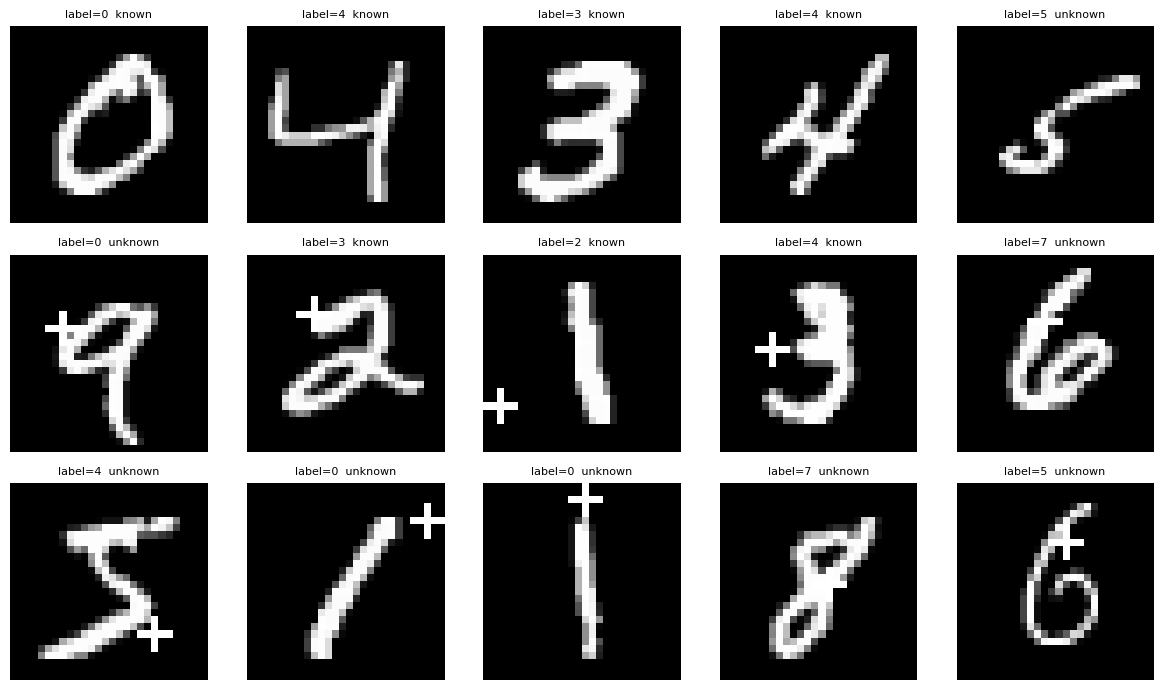

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
counts = {"none": 0, "left": 0, "right": 0}
row_map = {"none": 0, "left": 1, "right": 2}

for idx in range(len(train_ds)):
    item = train_ds[idx]
    mark = item["mark"]
    if counts[mark] < 5:
        r = row_map[mark]
        ax = axes[r, counts[mark]]
        ax.imshow(item["image"].squeeze(), cmap="gray")
        ax.set_title(
            f"label={item['label']}  {'known' if item['is_known'] else 'unknown'}",
            fontsize=8,
        )
        ax.axis("off")
        counts[mark] += 1
    if all(c >= 5 for c in counts.values()):
        break

for r, name in enumerate(["Unmarked", "Left-marked", "Right-marked"]):
    axes[r, 0].set_ylabel(name, fontsize=11)
fig.tight_layout()
plt.show()

## Train classifier

A single 10-class classifier trained on all data (including marks and label shifts).

In [4]:
classifier = Classifier().to(device)
cls_opt = torch.optim.Adam(classifier.parameters(), lr=1e-3)

for epoch in range(5):
    classifier.train()
    total_loss, n = 0.0, 0
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        cls_opt.zero_grad()
        loss = nn.functional.cross_entropy(classifier(images), labels)
        loss.backward()
        cls_opt.step()
        total_loss += loss.item() * len(images)
        n += len(images)
    print(f"epoch {epoch + 1}/5  loss={total_loss / n:.4f}")

classifier.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        preds = classifier(batch["image"].to(device)).argmax(dim=-1)
        correct += preds.eq(batch["label"].to(device)).sum().item()
        total += len(batch["image"])
print(f"classifier test_acc={correct / total:.4f}")

epoch 1/5  loss=1.3235
epoch 2/5  loss=0.6581
epoch 3/5  loss=0.3907
epoch 4/5  loss=0.2848
epoch 5/5  loss=0.2282
classifier test_acc=0.9215


## Pre-train gate

This time, we pre-train the gate. The gate is trained on known samples only, using BCE loss to predict whether an image is marked. Since known samples are low digits (0–4) that are either unmarked or left-marked, the gate has never seen right-marks or high digits during pre-training. You can see in the evaluation that it struggles with right-marked images. This means that using the gate to extend the labels and combining these new labels naively with unlearning would lead to preoblems (unlearning too little or too much).

In [12]:
known_idx = np.where(train_ds.is_known_arr)[0]
gate_loader = DataLoader(Subset(train_ds, known_idx), batch_size=128, shuffle=True)

gate = Gate().to(device)
gate_opt = torch.optim.Adam(gate.parameters(), lr=1e-3)
bce = nn.BCELoss()

for epoch in range(1):
    gate.train()
    for batch in gate_loader:
        images = batch["image"].to(device)
        targets = batch["is_marked"].to(device, dtype=torch.float32).unsqueeze(1)
        gate_opt.zero_grad()
        loss = bce(gate(images), targets)
        loss.backward()
        gate_opt.step()

gate.eval()
mark_acc = {"left": [0, 0], "right": [0, 0], "none": [0, 0]}
with torch.no_grad():
    for batch in test_loader:
        preds = gate(batch["image"].to(device)).squeeze(1) >= 0.5
        is_marked = batch["is_marked"].to(device, dtype=torch.bool)
        marks = batch["mark"]
        correct = preds.eq(is_marked)
        for i, m in enumerate(marks):
            mark_acc[m][0] += int(correct[i].item())
            mark_acc[m][1] += 1

print("gate accuracy by mark type:")
for name, (c, t) in mark_acc.items():
    print(f"  {name:12s} {c / t:.4f}  ({c}/{t})")

gate accuracy by mark type:
  left         0.9030  (2875/3184)
  right        0.0500  (167/3341)
  none         0.9471  (3291/3475)


## System training

The system starts from two copies of the pre-trained classifier and the pre-trained gate. `model_unsafe` is frozen; only `model_safe` and the gate are trainable. Three losses drive training:

- **Classification loss**: NLL on the system's mixed prediction (this is the loss we used in Experiment 1)
- **Gate supervision loss**: BCE on the gate output vs `is_marked` on known samples only
- **Divergence loss**: negative L2 distance between `model_safe` and `model_unsafe` parameters, pushing them apart (this plays the role of unlearning task B from model A)

As you can see, the whole system still performs well on all data, while the safe model unlearns marked-data behavior and specializes on unmarked data, exactly the way we wanted to. This means we can selectively remove capabilities from a model even if we only have partially labelled data (in this setting, at least), while preserving the beahvior of the whole system. This allows us to monitor when the capabilities are being used (when model B gets activated) and even turn them off for specific inputs (or in specific contexts).

In [14]:
model_safe = Classifier().to(device)
model_safe.load_state_dict(classifier.state_dict())
model_unsafe = Classifier().to(device)
model_unsafe.load_state_dict(classifier.state_dict())
for p in model_unsafe.parameters():
    p.requires_grad = False

system = GatedSystem(gate=gate, model_safe=model_safe, model_unsafe=model_unsafe)
optimizer = torch.optim.Adam(
    list(system.gate.parameters()) + list(system.model_safe.parameters()), lr=2e-3
)

W_CLS, W_GATE, W_DIV = 1.0, 1.0, 0.2
gate_log = {"step": [], "unmarked": [], "marked": []}

EPOCHS = 5
step = 0
for epoch in range(1, EPOCHS + 1):
    system.train()
    total_loss, n = 0.0, 0
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        is_known = batch["is_known"]
        is_marked = batch["is_marked"]

        optimizer.zero_grad()
        out = system(images)

        L_cls = nn.functional.nll_loss(
            torch.log(out["prediction"].clamp(min=1e-8)), labels
        )

        target = is_marked.to(device=device, dtype=out["gate"].dtype).unsqueeze(1)
        mask = is_known.to(device=device, dtype=out["gate"].dtype).unsqueeze(1)
        L_gate = (
            nn.functional.binary_cross_entropy(out["gate"], target, reduction="none")
            * mask
        ).sum() / (mask.sum() + 1e-8)

        diffs = torch.cat(
            [
                (ps - pu.detach()).flatten()
                for ps, pu in zip(
                    system.model_safe.parameters(), system.model_unsafe.parameters()
                )
            ]
        )
        L_div = -diffs.norm(2)

        loss = W_CLS * L_cls + W_GATE * L_gate + W_DIV * L_div
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)
        n += len(images)

        with torch.no_grad():
            g = out["gate"].squeeze(1)
            is_m = is_marked.to(device, dtype=torch.bool)
            gate_log["step"].append(step)
            gate_log["unmarked"].append(g[~is_m].mean().item())
            gate_log["marked"].append(g[is_m].mean().item())
        step += 1

    print(f"epoch {epoch}/{EPOCHS}  loss={total_loss / n:.4f}")


def evaluate(system, loader, force_gate=None):
    system.eval()
    counts = {"unmarked": [0, 0], "marked": [0, 0], "all": [0, 0]}
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            is_m = batch["is_marked"].to(device, dtype=torch.bool)
            out = system(images)
            if force_gate is not None:
                g = torch.full_like(out["gate"], force_gate)
                p_safe = torch.softmax(out["safe_logits"], dim=-1)
                p_unsafe = torch.softmax(out["unsafe_logits"], dim=-1)
                preds = ((1 - g) * p_safe + g * p_unsafe).argmax(dim=-1)
            else:
                preds = out["prediction"].argmax(dim=-1)
            eq = preds.eq(labels)
            counts["unmarked"][0] += eq[~is_m].sum().item()
            counts["unmarked"][1] += (~is_m).sum().item()
            counts["marked"][0] += eq[is_m].sum().item()
            counts["marked"][1] += is_m.sum().item()
            counts["all"][0] += eq.sum().item()
            counts["all"][1] += len(eq)
    return {k: c / t if t else float("nan") for k, (c, t) in counts.items()}


for name, fg in [
    ("system (gate learned)", None),
    ("safe only (gate=0)", 0.0),
    ("unsafe only (gate=1)", 1.0),
]:
    print(f"\n--- {name} ---")
    for k, v in evaluate(system, test_loader, force_gate=fg).items():
        print(f"  {k:12s} {v:.4f}")

mark_acc = {"left": [0, 0], "right": [0, 0], "none": [0, 0]}
with torch.no_grad():
    for batch in test_loader:
        preds = system.gate(batch["image"].to(device)).squeeze(1) >= 0.5
        is_marked = batch["is_marked"].to(device, dtype=torch.bool)
        marks = batch["mark"]
        correct = preds.eq(is_marked)
        for i, m in enumerate(marks):
            mark_acc[m][0] += int(correct[i].item())
            mark_acc[m][1] += 1

print(f"\n--- gate accuracy ---")
for name, (c, t) in mark_acc.items():
    print(f"  {name:12s} {c / t:.4f}")

epoch 1/5  loss=-20.8750
epoch 2/5  loss=-68.3088
epoch 3/5  loss=-119.6151
epoch 4/5  loss=-171.4161
epoch 5/5  loss=-223.8253

--- system (gate learned) ---
  unmarked     0.9542
  marked       0.9258
  all          0.9357

--- safe only (gate=0) ---
  unmarked     0.9629
  marked       0.0503
  all          0.3674

--- unsafe only (gate=1) ---
  unmarked     0.9053
  marked       0.9301
  all          0.9215

--- gate accuracy ---
  left         0.9887
  right        0.9796
  none         0.9396


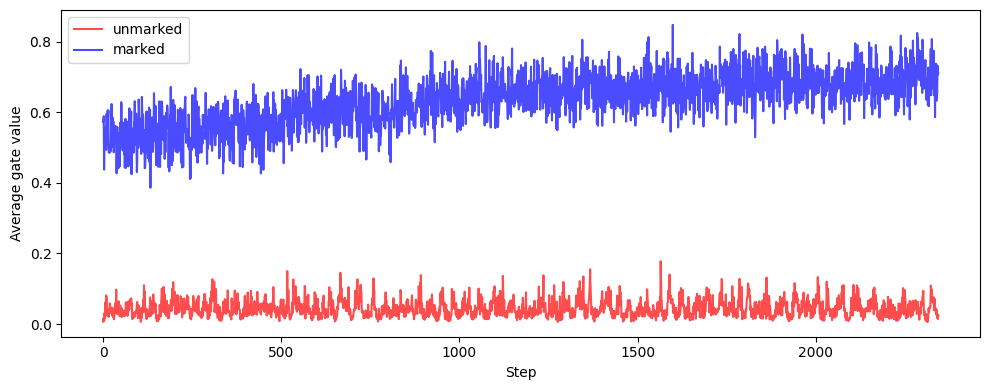

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(
    gate_log["step"], gate_log["unmarked"], color="red", label="unmarked", alpha=0.7
)
plt.plot(gate_log["step"], gate_log["marked"], color="blue", label="marked", alpha=0.7)
plt.xlabel("Step")
plt.ylabel("Average gate value")
plt.legend()
plt.tight_layout()
plt.show()